对基决策树的每个结点，从集合属性中随机选择包含 k 个属性的子集，从这个子集里进行最优属性的划分

随机森林中基学习器的多样性不仅来自样本的扰动，还来自属性的扰动
进一步降低了模型的方差，提高泛化能力

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X, y = make_moons(n_samples=1000, noise=0.22, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [11]:
single_tree = DecisionTreeClassifier(random_state=42)

rf = RandomForestClassifier(
    n_estimators=1000,      # 树的数量
    max_depth=4,            # 限制单树深度，防止过拟合
    max_features="sqrt",    # 每棵树随机选取sqrt(n_features)个特征（RF标准）
    bootstrap=True,         # 自助采样
    oob_score=True,         # 开启包外样本评估
    random_state=42,
    n_jobs=-1               # 使用全部CPU并行
)

single_tree.fit(X_train, y_train)
rf.fit(X_train, y_train)

,n_estimators,1000
,criterion,'gini'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [13]:
def show_acc(model, name):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    print(f"{name:18s} | 训练集Acc:{train_acc:.4f} | 测试集Acc:{test_acc:.4f}")

show_acc(single_tree, "Single DecisionTree")
show_acc(rf, "RandomForest")
print(f"\nOOB包外准确率: {rf.oob_score_:.4f}")

Single DecisionTree | 训练集Acc:1.0000 | 测试集Acc:0.9467
RandomForest       | 训练集Acc:0.9300 | 测试集Acc:0.9200

OOB包外准确率: 0.9100


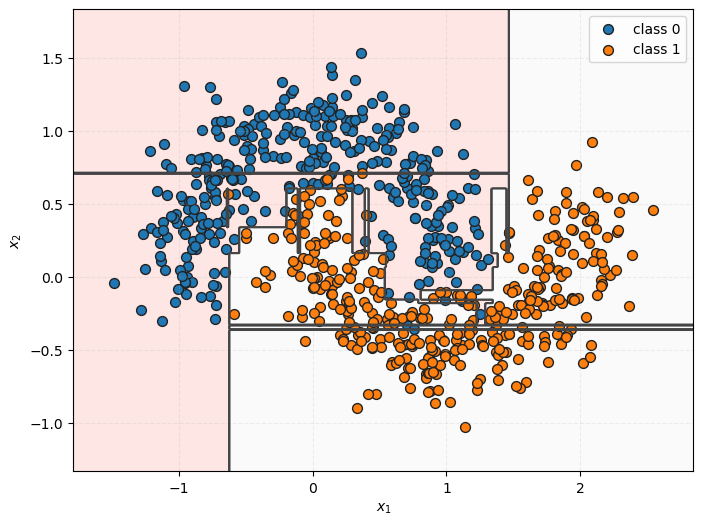

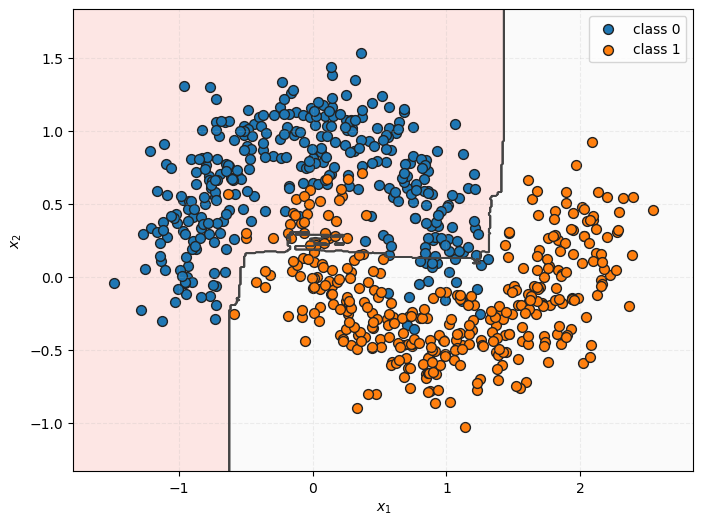

In [12]:
def plot_decision_boundary(clf, X, y, title=None):
    plt.figure(figsize=(8,6))
    x0_min, x0_max = X[:,0].min() - 0.3, X[:,0].max() + 0.3
    x1_min, x1_max = X[:,1].min() - 0.3, X[:,1].max() + 0.3
    xx0, xx1 = np.meshgrid(np.linspace(x0_min, x0_max, 500),
                           np.linspace(x1_min, x1_max, 500))
    grid = np.c_[xx0.ravel(), xx1.ravel()]
    pred = clf.predict(grid).reshape(xx0.shape)

    plt.contourf(xx0, xx1, pred, alpha=0.32, cmap="Pastel1")
    plt.contour(xx0, xx1, pred, colors="#444444", linewidths=0.75)

    # 画出样本
    for label in np.unique(y):
        mask = (y == label)
        plt.scatter(X[mask,0], X[mask,1], s=50, edgecolors="#222222", label=f"class {label}")
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.2, linestyle="--")
    plt.show()

plot_decision_boundary(single_tree, X_train, y_train)
plot_decision_boundary(rf, X_train, y_train)

In [16]:
print(single_tree.feature_importances_)
print(rf.feature_importances_)

[0.50486862 0.49513138]
[0.42693523 0.57306477]
